In [61]:
import torch
import random
from tqdm import tqdm

from src.model.encoder.pose_encoder import HandPoseEncoder
from src.data.dataset import CollectedDailyDataset

opt = {
    "annotation_path": "data/csl-daily/sentence_label/csl2020ct_v2.pkl",
    "max_length": 90,
    "upsample_factor": 3,
    "modalities": {
        "use_pred_pose": True,
        "use_features": False, 
        "use_raw_pose": False,
        "use_gt_pose": False
    },
    "pose_config": {
        "pose_dir": "poses",
        "norm_pose": True, 
    }
}

dataset = CollectedDailyDataset(opt, split_path='dataset/collected-demo/all.json')

In [68]:
# Load pretrained pose encoder
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pose_encoder = HandPoseEncoder(input_dim=3, hidden_dim=64, output_dim=768).to(device)
pose_encoder.load_state_dict(torch.load('weights/hand_pose_encoder_from_wavellm_mt5_daily_pose_0521_v1.bin', weights_only=True))
pose_encoder.eval()  # Set to eval mode
print("Successfully loaded pretrained pose encoder")

# Get dataset length
dataset_len = len(dataset)
print(f"Dataset size: {dataset_len}")

# Get all unique labels first
all_labels = []
for i in range(dataset_len):
    item = dataset[i]
    label = int(item['id'][-2])
    all_labels.append(label)
all_labels = torch.tensor(all_labels)
unique_labels = torch.unique(all_labels)
num_classes = len(unique_labels)
print(f"Number of classes: {num_classes}")

# For each class, keep one sample for test set
test_indices = []
for label in unique_labels:
    label_indices = torch.where(all_labels == label)[0]
    test_indices.append(random.choice(label_indices))  # Take random sample of each class
test_indices = torch.stack(test_indices)

# Remaining indices go to train set
train_mask = torch.ones(dataset_len, dtype=torch.bool)
train_mask[test_indices] = False
train_indices = torch.arange(dataset_len)[train_mask]

print(f"Train set size: {len(train_indices)}, Test set size: {len(test_indices)}")

# Define a simple classifier
class SimpleClassifier(torch.nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256, num_classes=10):
        super().__init__()
        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(hidden_dim, num_classes)
        )
    
    def forward(self, x):
        return self.classifier(x)
    
    def get_hidden_features(self, x):
        return self.classifier[0](x)

# Get training and test data
print("Collecting training data...")
with torch.no_grad():  # No gradients needed
    train_features = []
    train_labels = []
    for i in train_indices:
        item = dataset[i]
        label = int(item['id'][-2])
        joints = item['joints'].unsqueeze(0).to(device)
        features = pose_encoder(joints)
        features = features.squeeze(0)
        max_idx = torch.norm(features, dim=1).argmax()
        train_features.append(features[max_idx])
        train_labels.append(label)

    print("Collecting test data...")        
    test_features = []
    test_labels = []
    for i in test_indices:
        item = dataset[i]
        label = int(item['id'][-2])
        joints = item['joints'].unsqueeze(0).to(device)
        features = pose_encoder(joints)
        features = features.squeeze(0)
        max_idx = torch.norm(features, dim=1).argmax()
        test_features.append(features[max_idx])
        test_labels.append(label)

# Convert to tensors
train_features = torch.stack(train_features)
train_labels = torch.tensor(train_labels).to(device)
test_features = torch.stack(test_features)
test_labels = torch.tensor(test_labels).to(device)

# Initialize model and optimizer
model = SimpleClassifier(num_classes=num_classes).to(device)

# Initialize optimizer for classifier only
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

# Train model
print("Starting training...")
num_epochs = 200
for epoch in tqdm(range(num_epochs)):
    model.train()
    # Zero gradients
    optimizer.zero_grad()
    # Forward pass through classifier
    outputs = model(train_features)
    loss = criterion(outputs, train_labels)
    # Backward pass and optimization
    loss.backward()
    optimizer.step()
    # Evaluate model
    model.eval()
    with torch.no_grad():
        train_preds = torch.argmax(model(train_features), dim=1)
        train_acc = (train_preds == train_labels).float().mean()
        
        test_preds = torch.argmax(model(test_features), dim=1)
        test_acc = (test_preds == test_labels).float().mean()
        
print(f"Training accuracy: {train_acc:.4f}, Test accuracy: {test_acc:.4f}")

Successfully loaded pretrained pose encoder
Dataset size: 78
Number of classes: 8
Train set size: 70, Test set size: 8
Starting training...


100%|██████████| 200/200 [00:00<00:00, 1030.54it/s]

Training accuracy: 1.0000, Test accuracy: 1.0000


100%|██████████| 78/78 [00:00<00:00, 95.95it/s]


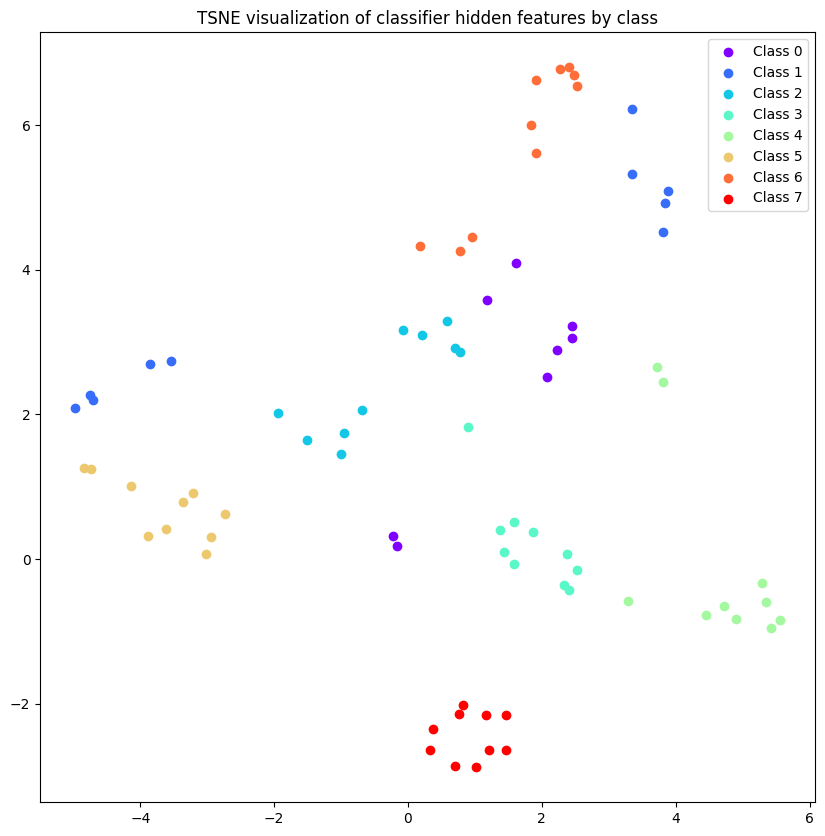

In [69]:
# Get features and labels for all samples
all_features = []
all_labels = []
for i in tqdm(range(len(dataset))):
    # Get label from ID
    item = dataset[i]
    label = item['id'][-2]  # Get second to last character as label
    
    joints = item['joints'].to(device) # [T, 2, 24, 3]
    joints = joints.unsqueeze(0) # Add batch dimension [1, T, 2, 24, 3]
    with torch.no_grad():
        # Get pose encoder features
        pose_features = pose_encoder(joints) # [1, T, feature_dim]
        pose_features = pose_features.squeeze(0) # [T, feature_dim]
        # Get feature at max activation
        max_idx = torch.norm(pose_features, dim=1).argmax()
        pose_feature = pose_features[max_idx]
        
        # Get classifier first layer features
        hidden_feature = model.get_hidden_features(pose_feature.unsqueeze(0))
        all_features.append(hidden_feature.squeeze(0).cpu())
        all_labels.append(label)

all_features = torch.stack(all_features)
all_labels = torch.tensor([int(l) for l in all_labels])

# Convert to tensor and do TSNE
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Do TSNE dimensionality reduction
tsne = TSNE(n_components=2, random_state=42)
features_2d = tsne.fit_transform(all_features.numpy())

# Plot with different colors for each class
plt.figure(figsize=(10,10))
unique_labels = torch.unique(all_labels)
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    mask = all_labels == label
    plt.scatter(features_2d[mask,0], features_2d[mask,1], 
               c=[color], label=f'Class {label}',
               alpha=1.0)

plt.title('TSNE visualization of classifier hidden features by class')
plt.legend()
plt.show()